# Trabalho de Fundamentos em Ciência de Dados
## Tema: Análise do Histórico e Correlação do Bitcoin
### Alunos
- Pedro Henrique de Oliveira Covisi
- Lucca Teodoro Vaz

---

### Instruções para o Trabalho
1) Descrição do problema e dos dados
- Apresentar o tema escolhido;
- Descrever a origem da base de dados;
- Explicar os objetivos ou perguntas que serão investigadas.
2) Preparação dos dados
- Identificar e tratar valores ausentes ou inconsistentes;
- Remover duplicidades, quando necessário;
- Descrever as etapas de limpeza e pré-processamento dos dados.
3) Análise exploratória dos dados
Realizar análises utilizando tabelas e gráficos para responder às perguntas propostas.
Exemplos:
- Distribuição das variáveis;
- Comparação entre grupos;
- Associações entre variáveis;
- Identificação de padrões ou tendências.
Devem ser utilizados pelo menos três tipos diferentes de visualização de dados, como histogramas, gráficos de barras, gráficos de dispersão, boxplots, entre outros.
4) Resultados e conclusões
- Apresentar os principais resultados encontrados;
- Discutir possíveis limitações da base de dados;
- Destacar conclusões e aplicações do estudo

## 1) Descrição do Problema e dos Dados

### 1.1) Tema Escolhido

O tema escolhido foi a análise do histórico e da correlação do Bitcoin com outros ativos financeiros. Assim, nosso objetivo é fazer uma análise profunda da cotação do Bitcoin e da sua correlação, que mudou ao longo dos anos, com outros ativos financeiros relevantes, como o Petróleo, Bolsas Americana e Brasileira, Ouro, Ethereum (segunda maior criptomoeda), Títulos do Tesouro, entre outros. Escolhemos esse tema devido ao grande interesse que temos no mercado financeiro e na influência que o Bitcoin, e outras criptomoedas, vem ganhando com o passar do tempo.

### 1.2) Origem da Base de Dados

Para a realização deste trabalho, são utilizadas duas fontes de dados principais:

1. **Yahoo Finance API (via biblioteca yfinance):**
   Os dados financeiros são coletados dinamicamente utilizando a biblioteca `yfinance` em Python, cobrindo o período a partir de **09/11/2017**. São extraídas as métricas diárias de preço de Abertura (*Open*), Máxima (*High*), Mínima (*Low*) e Fechamento (*Close*) para os seguintes ativos:
   - **Bitcoin (BTC-USD):** Principal criptomoeda e foco central deste estudo.
   - **Ethereum (ETH-USD):** Segunda maior criptomoeda do mercado, para análise de correlação intrassetorial.
   - **S&P 500 (^GSPC):** Índice das 500 maiores empresas dos EUA, representando o mercado de ações americano.
   - **Nasdaq (^IXIC):** Índice de ações composto majoritariamente por empresas de tecnologia.
   - **Ibovespa (^BVSP):** Principal índice de ações do mercado brasileiro.
   - **Ouro (GC=F):** Contratos futuros de ouro, utilizado como commodity de segurança/reserva de valor.
   - **Petróleo (CL=F):** Contratos futuros de petróleo bruto (WTI), representando a principal commodity energética.
   - **Dólar (DX-Y.NYB):** Índice DXY, que mensura o desempenho do dólar americano contra uma cesta de moedas fortes.

2. **Base de Dados Histórica do Bitcoin (bitcoin_dataset.csv):**
   Um conjunto de dados histórico local armazenado em `data/bitcoin_dataset.csv` com dados diários do preço do Bitcoin desde **17/09/2014**. As variáveis incluem as datas e os valores de Abertura (*Open*), Máxima (*High*), Mínima (*Low*), Fechamento (*Close*), Fechamento Ajustado (*Adj Close*) e Volume de negociação.

### 1.3) Objetivos e Perguntas de Pesquisa
1) Fornecer uma breve contextualização sobre o Bitcoin;
2) Responder as seguintes Perguntas:
- BTC é lucrativo a longo prazo?
- BTC é mais arricado do que os ativos tradicionais?
- O mercado do Bitcoin apresenta sazonalidade ?
- BTC é uma reserva de valor?
- O bitcoin possue correlação com outros ativos financeiros ?
    - Como ela se apresenta ?
    - Qual o papel da institucionalização ( ETFs ) nesse movimento

---

## 2) Preparação dos Dados

### 2.1) Importação e Limpeza dos Dados dos Ativos Financeiros

#### Importando as bibliotecas

In [62]:
# Instalação de bibliotecas necessárias para o Google Colab
#!pip install kaggle python-dotenv


In [63]:
# Importação das bibliotecas necessárias para análise de dados, visualização e coleta de dados financeiros
import os
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import zipfile


#### Imortando os Dados

Observação: Decidimos por importar os dados do Bitcoin do Etherium e dos demais ativos financeiros em dataframes diferentes por causa da quantidade de dados disponíveis. Os dados do BTC, pelo yahoo finance, começavama apenas em 2015, assim decidimos por um dataset mais antigo. O do etherium começava em 2017 apenas, assim se juntassemos com os demais ativos ( que começam em 2012 ) perderiamos precisão na análise por ter que lidar com dados faltantes ( sem contar que o etherium, diferentemente dos outros ativos, é negociado aos fim de semana e feriados, o que seriam mais dados faltantes para tratar )

**Importando dados do BTC pelo Kaggle (desde 2012)**

In [64]:
# Autenticação da API do Kaggle
try:
    # Tenta carregar as chaves do cofre secreto do Google Colab
    from google.colab import userdata
    os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
    os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')
    print("✅ Rodando no Google Colab. Credenciais carregadas dos Secrets.")
except ImportError:
    # Se der erro de ImportError, significa que não estamos no Colab, mas sim no VS Code.
    # Então carrega do arquivo .env escondido na sua máquina.
    from dotenv import load_dotenv
    load_dotenv()
    print("💻 Rodando localmente. Credenciais carregadas do arquivo .env.")



💻 Rodando localmente. Credenciais carregadas do arquivo .env.


In [65]:
import kaggle

dataset_name = 'mczielinski/bitcoin-historical-data' 

print(f"Baixando {dataset_name} da API do Kaggle...")

# Baixando e extraindo o CSV
kaggle.api.dataset_download_files(dataset_name, path='../data', unzip=True)
print("Download concluído com sucesso!")


Baixando mczielinski/bitcoin-historical-data da API do Kaggle...
Dataset URL: https://www.kaggle.com/datasets/mczielinski/bitcoin-historical-data
Download concluído com sucesso!


In [66]:

# Lendo o CSV
nome_do_arquivo_csv = 'bitstampUSD_1-min_data_2012-01-01_to_2021-03-31.csv'
caminho_csv = f'../data/{'btcusd_1-min_data.csv'}'

# Importando para o Pandas
df_btc = pd.read_csv(caminho_csv)

# Transformando Timestamp em data
if 'Timestamp' in df_btc.columns:
    df_btc['Date'] = pd.to_datetime(df_btc['Timestamp'], unit='s')
    df_btc.set_index('Date', inplace=True)

# Transformando em diário
df_btc = df_btc['Close'].resample('D').last().to_frame()
df_btc.columns = ['Bitcoin']

df_btc

,Bitcoin
Date,
2012-01-01,5.00
2012-01-02,5.00
2012-01-03,5.29
2012-01-04,5.57
2012-01-05,6.65
...,...
2026-06-27,59940.07
2026-06-28,59473.29
2026-06-29,60163.86


**Importando os dados do ETH pelo Yahoo Finance (Desde 2017)**

In [67]:
df_eth = yf.download('ETH-USD', start="2017-11-09")
metricas_desejadas = ['Open', 'High', 'Low', 'Close']
df_eth = df_eth[metricas_desejadas]
df_eth

[*********************100%***********************]  1 of 1 completed


Price,Open,High,Low,Close
Ticker,ETH-USD,ETH-USD,ETH-USD,ETH-USD
Date,,,,
2017-11-09,308.644989,329.451996,307.056000,320.884003
2017-11-10,320.670990,324.717987,294.541992,299.252991
2017-11-11,298.585999,319.453003,298.191986,314.681000
2017-11-12,314.690002,319.153015,298.513000,307.907990
2017-11-13,307.024994,328.415009,307.024994,316.716003
...,...,...,...,...
2026-06-27,1576.591187,1607.865967,1561.972900,1571.588257
2026-06-28,1571.564453,1585.219727,1548.761963,1570.361206


**Importando os dados dos demais ativos financeiros do Yahoo Finance (Desde 2012)**

In [68]:
# Definição dos tickers dos ativos a serem importados
tickers_ativos = [
    "^GSPC", # S&P 500
    "^IXIC", # Nasdaq
    "^BVSP", # Bovespa
    "GC=F", # Ouro
    "CL=F", # Petróleo
    "DX-Y.NYB", # Dólar
]

# Download dos dados históricos dos ativos
df_ativos = yf.download(tickers_ativos, start="2012-01-01")

# Filtragem das métricas de preço desejadas
metricas_desejadas = ['Open', 'High', 'Low', 'Close']
df_filtrado = df_ativos[metricas_desejadas]

df_ativos = df_filtrado
# Visualização das primeiras linhas dos dados importados
df_ativos.head(20)


[*********************100%***********************]  6 of 6 completed


Price             Open                                                \
Ticker            CL=F   DX-Y.NYB         GC=F    ^BVSP        ^GSPC   
Date                                                                   
2012-01-03   99.699997  80.230003  1568.900024  57836.0  1258.859985   
2012-01-04  102.989998  79.650002  1596.599976  59263.0  1277.030029   
2012-01-05  103.290001  80.150002  1610.800049  59354.0  1277.300049   
2012-01-06  101.349998  80.900002  1622.500000  58565.0  1280.930054   
2012-01-09  101.919998  81.430000  1614.300049  58601.0  1277.829956   
2012-01-10  101.300003  80.919998  1619.900024  59090.0  1280.770020   
2012-01-11  102.199997  80.989998  1634.800049  59799.0  1292.020020   
2012-01-12  101.000000  81.250000  1645.199951  59966.0  1292.479980   
2012-01-13   99.199997  80.820000  1638.900024  59918.0  1294.819946   
2012-01-16         NaN        NaN          NaN  59146.0          NaN   
2012-01-17   98.949997  81.419998  1643.699951  59961.0  1290.219971   
2012-01-18  100.910004  81.080002  1654.000000  60643.0  1293.650024   
2012-01-19  101.139999  80.480003  1663.000000  61726.0  1308.069946   
2012-01-20  100.389999  80.089996  1652.800049  61932.0  1314.489990   
2012-01-23   98.339996  80.370003  1676.900024  62312.0  1315.290039   
2012-01-24   99.879997  79.750000  1666.900024  62386.0  1315.959961   
2012-01-25   99.199997  79.800003  1673.000000      NaN  1314.400024   
2012-01-26   99.959999  79.489998  1729.000000  62486.0  1326.280029   
2012-01-27   99.930000  79.449997  1727.000000  62955.0  1318.250000   
2012-01-30  100.000000  78.900002  1737.199951  62902.0  1316.160034   

Price                          High                                   ...  \
Ticker            ^IXIC        CL=F   DX-Y.NYB         GC=F    ^BVSP  ...   
Date                                                                  ...   
2012-01-03  2657.389893  103.180000  80.389999  1604.300049  59288.0  ...   
2012-01-04  2639.899902  103.739998  80.320000  1618.599976  59519.0  ...   
2012-01-05  2642.570068  103.730003  81.010002  1624.099976  59354.0  ...   
2012-01-06  2671.169922  102.800003  81.370003  1627.800049  59261.0  ...   
2012-01-09  2682.979980  102.150002  81.500000  1620.099976  59220.0  ...   
2012-01-10  2704.419922  103.410004  81.470001  1638.000000  60112.0  ...   
2012-01-11  2695.770020  102.459999  81.489998  1645.400024  60094.0  ...   
2012-01-12  2716.870117  102.980003  81.489998  1656.099976  60504.0  ...   
2012-01-13  2707.409912  100.190002  81.779999  1643.400024  59918.0  ...   
2012-01-16          NaN         NaN        NaN          NaN  59982.0  ...   
2012-01-17  2736.340088  101.010002  81.699997  1657.800049  60891.0  ...   
2012-01-18  2731.159912  102.059998  81.449997  1660.300049  61723.0  ...   
2012-01-19  2779.739990  102.059998  81.120003  1664.400024  62181.0  ...   
2012-01-20  2776.040039  100.739998  80.580002  1664.300049  62312.0  ...   
2012-01-23  2786.209961  100.239998  80.389999  1680.000000  62693.0  ...   
2012-01-24  2771.580078  100.180000  80.389999  1668.199951  62536.0  ...   
2012-01-25  2803.229980  100.400002  80.349998  1706.199951      NaN  ...   
2012-01-26  2828.780029  101.389999  79.540001  1729.000000  63805.0  ...   
2012-01-27  2797.659912  100.629997  79.540001  1734.099976  63263.0  ...   
2012-01-30  2790.399902  100.050003  79.449997  1739.900024  62902.0  ...   

Price               Low                                          Close  \
Ticker             GC=F    ^BVSP        ^GSPC        ^IXIC        CL=F   
Date                                                                     
2012-01-03  1566.000000  57836.0  1258.859985  2641.979980  102.959999   
2012-01-04  1594.500000  58558.0  1268.099976  2627.229980  103.220001   
2012-01-05  1597.800049  57963.0  1265.260010  2631.229980  101.809998   
2012-01-06  1616.099976  58355.0  1273.339966  2658.830078  101.559998   
2012-01-09  1607.500000  58599.0  1274.550049  2662.9

Mudando o nome das colunas para torná-las mais legíveis

In [69]:
# Renomeação das colunas para facilitar a identificação dos ativos
df_ativos = df_ativos.rename(columns={
    '^BVSP': 'Bovespa',
    '^GSPC': 'SP500',
    '^IXIC': 'Nasdaq',
    'CL=F': 'Petróleo',
    'GC=F': 'Ouro',
    'DX-Y.NYB' : 'Dólar'
})


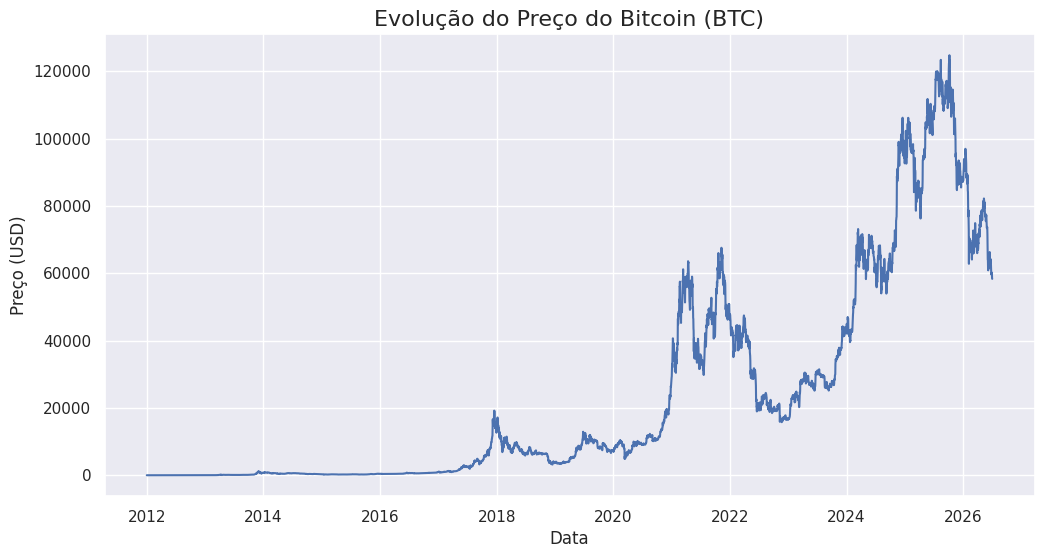

In [70]:
# Seleção do preço de fechamento do Bitcoin e ajuste do índice
btc_close = df_btc.reset_index()

# Configuração do tema visual dos gráficos
sns.set_theme(style='darkgrid')
plt.figure(figsize=(12,6))

# Plotagem do gráfico de linha para a evolução de preço
sns.lineplot(x='Date', y='Bitcoin', data=btc_close)

# Definição dos títulos e rótulos dos eixos
plt.title('Evolução do Preço do Bitcoin (BTC)', fontsize=16)
plt.xlabel('Data', fontsize=12)
plt.ylabel('Preço (USD)', fontsize=12)

# Exibição do gráfico gerado
plt.show()


### 2.2) Tratamento de Dados Faltantes

#### 2.2.1) Tratamento dos Dados Faltantes dos ativos Tradicionais

In [71]:
# Verificação de dados faltantes nos ativos importados
dados = df_ativos
# Contagem e exibição do número de registros nulos por ativo e métrica
dados.isna().sum()


Price  Ticker  
Open   Petróleo     92
       Dólar        91
       Ouro         93
       Bovespa     144
       SP500        92
       Nasdaq       92
High   Petróleo     92
       Dólar        91
       Ouro         93
       Bovespa     144
       SP500        92
       Nasdaq       92
Low    Petróleo     92
       Dólar        91
       Ouro         93
       Bovespa     144
       SP500        92
       Nasdaq       92
Close  Petróleo     92
       Dólar        91
       Ouro         93
       Bovespa     144
       SP500        92
       Nasdaq       92
dtype: int64

A partir dessa verificação, apresentam-se vários dados faltantes, os quais já eram esperados. Isso ocorre devido a divergência entre feriados no Brasil e nos Estados Unidos

Para lidar com isso, resolvemos excluir os dados faltantes ao invés de incluir dados artificiais já que, em nossa percepção, isso poderia afetar o estudo da correlação entre esses ativos e o Bitcoin ( além de que são poucos dados que não farão tanta diferença)

In [72]:
# Remoção de todas as linhas com valores ausentes
dados.dropna(inplace=True) 
# Verificação se restaram dados ausentes após a limpeza
dados.isna().sum()


Price  Ticker  
Open   Petróleo    0
       Dólar       0
       Ouro        0
       Bovespa     0
       SP500       0
       Nasdaq      0
High   Petróleo    0
       Dólar       0
       Ouro        0
       Bovespa     0
       SP500       0
       Nasdaq      0
Low    Petróleo    0
       Dólar       0
       Ouro        0
       Bovespa     0
       SP500       0
       Nasdaq      0
Close  Petróleo    0
       Dólar       0
       Ouro        0
       Bovespa     0
       SP500       0
       Nasdaq      0
dtype: int64

#### 2.2.2) Tratamento de Dados Faltantes do BTC

In [73]:
# Exibição dos dados exclusivos do Bitcoin importados anteriormente
df_btc


,Bitcoin
Date,
2012-01-01,5.00
2012-01-02,5.00
2012-01-03,5.29
2012-01-04,5.57
2012-01-05,6.65
...,...
2026-06-27,59940.07
2026-06-28,59473.29
2026-06-29,60163.86


In [74]:
df_btc.isna().sum()

Bitcoin    0
dtype: int64

#### 2.2.3) Tratamento de Dados Faltantes do Ethereum

In [75]:
# Exibição dos dados exclusivos do Ethereum importados anteriormente
df_eth


Price,Open,High,Low,Close
Ticker,ETH-USD,ETH-USD,ETH-USD,ETH-USD
Date,,,,
2017-11-09,308.644989,329.451996,307.056000,320.884003
2017-11-10,320.670990,324.717987,294.541992,299.252991
2017-11-11,298.585999,319.453003,298.191986,314.681000
2017-11-12,314.690002,319.153015,298.513000,307.907990
2017-11-13,307.024994,328.415009,307.024994,316.716003
...,...,...,...,...
2026-06-27,1576.591187,1607.865967,1561.972900,1571.588257
2026-06-28,1571.564453,1585.219727,1548.761963,1570.361206


In [76]:
df_eth.isna().sum()

Price  Ticker 
Open   ETH-USD    0
High   ETH-USD    0
Low    ETH-USD    0
Close  ETH-USD    0
dtype: int64

### 2.3) Cálculo dos Retornos Logarítmicos dos Ativos

Para garantir que as análises de correlação e os futuros modelos de previsão sejam estatisticamente consistentes, calculamos os retornos logarítmicos ($r_t = \ln(P_t / P_{t-1})$) a partir dos preços de fechamento diários (*Close*) de cada ativo.

**Principais motivos para usar os retornos logarítmicos:**
- **Simetria entre ganhos e perdas:** Por exemplo, se um ativo cai 50% e depois sobe 100% para retornar ao preço original, a soma simples dos retornos percentuais é +50% (o que é contraintuitivo), enquanto os retornos logarítmicos correspondentes têm a mesma magnitude mas sinais opostos, anulando-se mutuamente (soma igual a zero);
- **Aditividade no tempo:** O retorno logarítmico acumulado em vários períodos é a soma simples dos retornos de cada período individual;
- **Propriedades estatísticas:** Os retornos logarítmicos aproximam-se mais de uma distribuição normal.

In [77]:
# Unificação dos preços de fechamento dos três bancos de dados (BTC, ETH e demais ativos)
eth_close = df_eth['Close'].copy()
if isinstance(eth_close, pd.DataFrame) and 'ETH-USD' in eth_close.columns:
    eth_close = eth_close.rename(columns={'ETH-USD': 'Ethereum'})
elif isinstance(eth_close, pd.Series):
    eth_close = eth_close.to_frame(name='Ethereum')

df_fechamento = df_btc.join(eth_close, how='outer').join(df_ativos['Close'], how='outer')

# Substituição de valores menores ou iguais a zero por NaN para evitar erros no logaritmo
df_fechamento = df_fechamento.mask(df_fechamento <= 0)

# Cálculo do retorno logarítmico diário de todos os ativos
df_retornos_log = np.log(df_fechamento / df_fechamento.shift(1))

# Remoção da primeira linha (que fica com NaN após o shift) e de outros NaNs resultantes
df_retornos_log.dropna(inplace=True)

# Exibição das primeiras linhas do DataFrame de retornos logarítmicos unificado
df_retornos_log.head()


,Bitcoin,Ethereum,Petróleo,Dólar,Ouro,Bovespa,SP500,Nasdaq
Date,,,,,,,,
2017-11-10,-0.081555,-0.069790,-0.007550,-0.000530,-0.010321,-0.010545,-0.000898,0.000132
2017-11-14,0.012765,0.063948,-0.018852,-0.007009,0.003283,-0.023001,-0.002312,-0.002924
2017-11-17,-0.022159,0.004432,0.025250,-0.002879,0.014302,0.012676,-0.002629,-0.001547
2017-11-22,0.014649,0.054668,0.020723,-0.007800,0.008163,-0.001019,-0.000751,0.000711
2017-11-28,0.016423,-0.015637,-0.002067,0.003868,0.000695,0.001093,0.009800,0.004908


## 3) Análise Exploratória dos Dados

### 3.1) Bitcoin é lucrativo a longo Prazo ?

/tmp/ipykernel_12449/269217858.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Ativo', y='Anos para Dobrar', data=df_tempo_dobrar, palette='viridis')


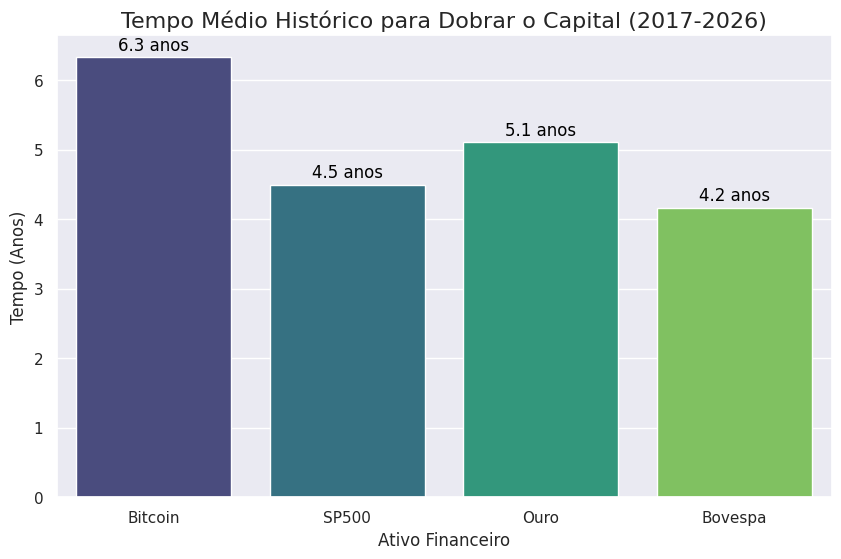

In [78]:
# Calculando o retorno logarítmico médio diário e anualizando (considerando 252 dias úteis)
retorno_medio_diario = df_retornos_log[['Bitcoin', 'SP500', 'Ouro', 'Bovespa']].mean()
retorno_medio_anual = retorno_medio_diario * 252

# Calculando o tempo para dobrar o capital (em anos)
# Usando a fórmula matemática exata: ln(2) / Retorno Anualizado
tempo_dobrar_anos = np.log(2) / retorno_medio_anual

# Convertendo a Série em um DataFrame para facilitar a plotagem no Seaborn
df_tempo_dobrar = tempo_dobrar_anos.reset_index()
df_tempo_dobrar.columns = ['Ativo', 'Anos para Dobrar']

# Plotando o Gráfico de Barras
plt.figure(figsize=(10, 6))
# O palette 'viridis' cria um degradê profissional de cores
ax = sns.barplot(x='Ativo', y='Anos para Dobrar', data=df_tempo_dobrar, palette='viridis')

# Adicionando os rótulos de dados (números) no topo de cada barra
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f} anos', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='baseline', 
                fontsize=12, color='black', xytext=(0, 5), 
                textcoords='offset points')

plt.title('Tempo Médio Histórico para Dobrar o Capital (2017-2026)', fontsize=16)
plt.xlabel('Ativo Financeiro', fontsize=12)
plt.ylabel('Tempo (Anos)', fontsize=12)

plt.show()


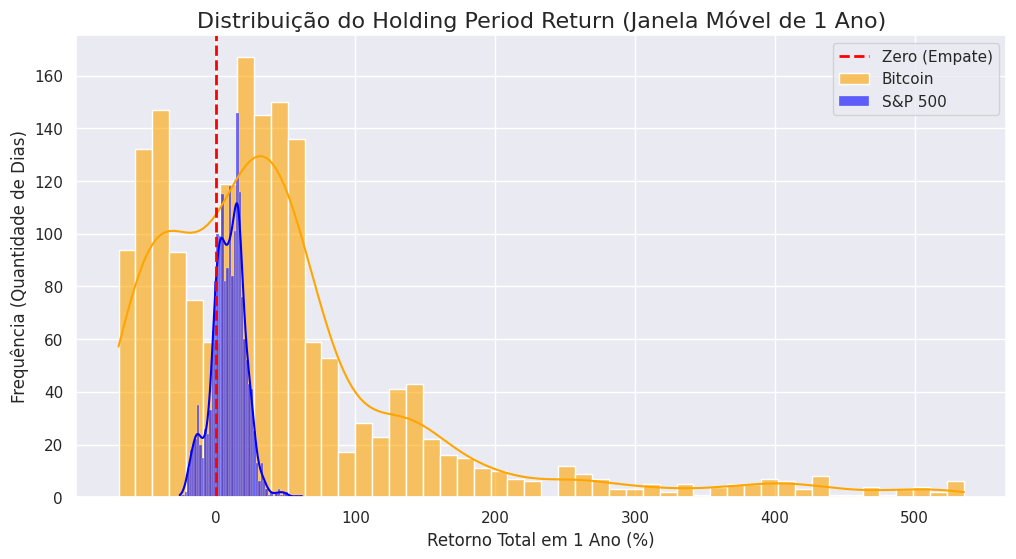

Probabilidade de lucro segurando BTC por 1 ano: 67.2%
Probabilidade de lucro segurando S&P 500 por 1 ano: 80.5%


In [91]:
# Definindo a janela do período de manutenção (ex: 1 ano = 252 dias úteis)
janela_hpr = 252

# Calculando o HPR Móvel (Preço de hoje / Preço de 252 dias atrás - 1)
# Usamos o DataFrame de preços de fechamento originais que foram limpos anteriormente
df_hpr_movel = (df_fechamento / df_fechamento.shift(janela_hpr)) - 1
df_hpr_movel = df_hpr_movel.dropna() * 100 # Em porcentagem

# Plotando a distribuição do HPR de 1 ano (Histograma)
plt.figure(figsize=(12, 6))

sns.histplot(df_hpr_movel['Bitcoin'], bins=50, kde=True, color='orange', alpha=0.6, label='Bitcoin')
sns.histplot(df_hpr_movel['SP500'], bins=50, kde=True, color='blue', alpha=0.6, label='S&P 500')

plt.axvline(0, color='red', linestyle='--', linewidth=2, label='Zero (Empate)')

plt.title('Distribuição do Holding Period Return (Janela Móvel de 1 Ano)', fontsize=16)
plt.xlabel('Retorno Total em 1 Ano (%)', fontsize=12)
plt.ylabel('Frequência (Quantidade de Dias)', fontsize=12)
plt.legend()


plt.show()

# Calculando a probabilidade de lucro (Taxa de Acerto)
prob_lucro_btc = (df_hpr_movel['Bitcoin'] > 0).mean() * 100
prob_lucro_sp = (df_hpr_movel['SP500'] > 0).mean() * 100

print(f"Probabilidade de lucro segurando BTC por 1 ano: {prob_lucro_btc:.1f}%")
print(f"Probabilidade de lucro segurando S&P 500 por 1 ano: {prob_lucro_sp:.1f}%")

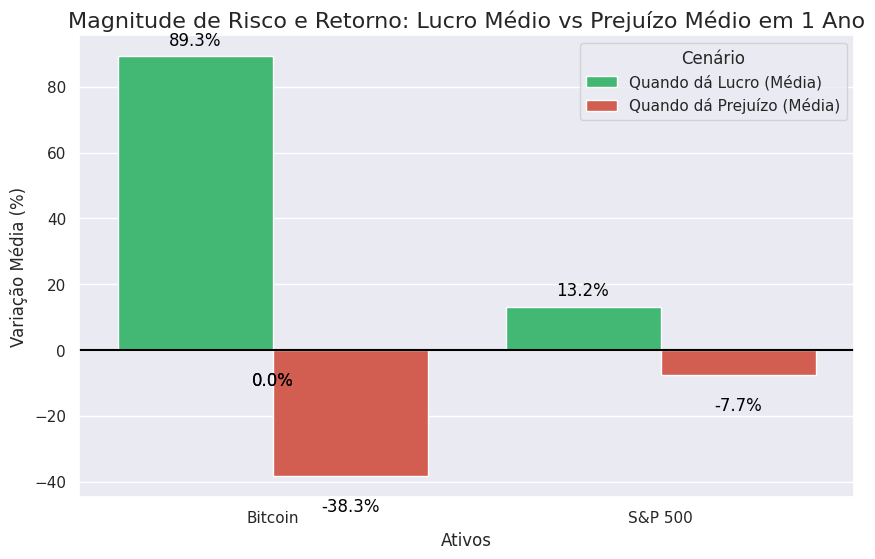

In [92]:
# Separando os cenários de Lucro e Prejuízo e calculando as médias
lucro_medio_btc = df_hpr_movel[df_hpr_movel['Bitcoin'] > 0]['Bitcoin'].mean()
prejuizo_medio_btc = df_hpr_movel[df_hpr_movel['Bitcoin'] < 0]['Bitcoin'].mean()

lucro_medio_sp = df_hpr_movel[df_hpr_movel['SP500'] > 0]['SP500'].mean()
prejuizo_medio_sp = df_hpr_movel[df_hpr_movel['SP500'] < 0]['SP500'].mean()

# Estruturando os dados para o Seaborn
import pandas as pd # Caso não esteja importado nesta célula

dados_assimetria = pd.DataFrame({
    'Ativo': ['Bitcoin', 'Bitcoin', 'S&P 500', 'S&P 500'],
    'Cenário': ['Quando dá Lucro (Média)', 'Quando dá Prejuízo (Média)', 'Quando dá Lucro (Média)', 'Quando dá Prejuízo (Média)'],
    'Retorno (%)': [lucro_medio_btc, prejuizo_medio_btc, lucro_medio_sp, prejuizo_medio_sp]
})

# Plotando o Gráfico de Barras Agrupadas
plt.figure(figsize=(10, 6))

# Usando Verde para lucro e Vermelho para prejuízo
cores = ['#2ecc71', '#e74c3c']
ax = sns.barplot(x='Ativo', y='Retorno (%)', hue='Cenário', data=dados_assimetria, palette=cores)

# Colocando os rótulos de dados (os números exatos) nas barras
for p in ax.patches:
    altura = p.get_height()
    # Ajuste de posição dependendo se a barra é positiva ou negativa
    va = 'bottom' if altura > 0 else 'top'
    y_offset = 5 if altura > 0 else -15

    ax.annotate(f'{altura:.1f}%',
                (p.get_x() + p.get_width() / 2., altura),
                ha='center', va=va,
                fontsize=12, color='black', xytext=(0, y_offset),
                textcoords='offset points')

# Linha preta grossa no eixo zero para separar lucros de prejuízos
plt.axhline(0, color='black', linewidth=1.5)

plt.title('Magnitude de Risco e Retorno: Lucro Médio vs Prejuízo Médio em 1 Ano', fontsize=16)
plt.xlabel('Ativos', fontsize=12)
plt.ylabel('Variação Média (%)', fontsize=12)

plt.show()


#### 3.2) O Bitcoin é mais arriscado que os ativos tradicionais ?
Obs: Estamos considerando apenas o risco de volatilidade

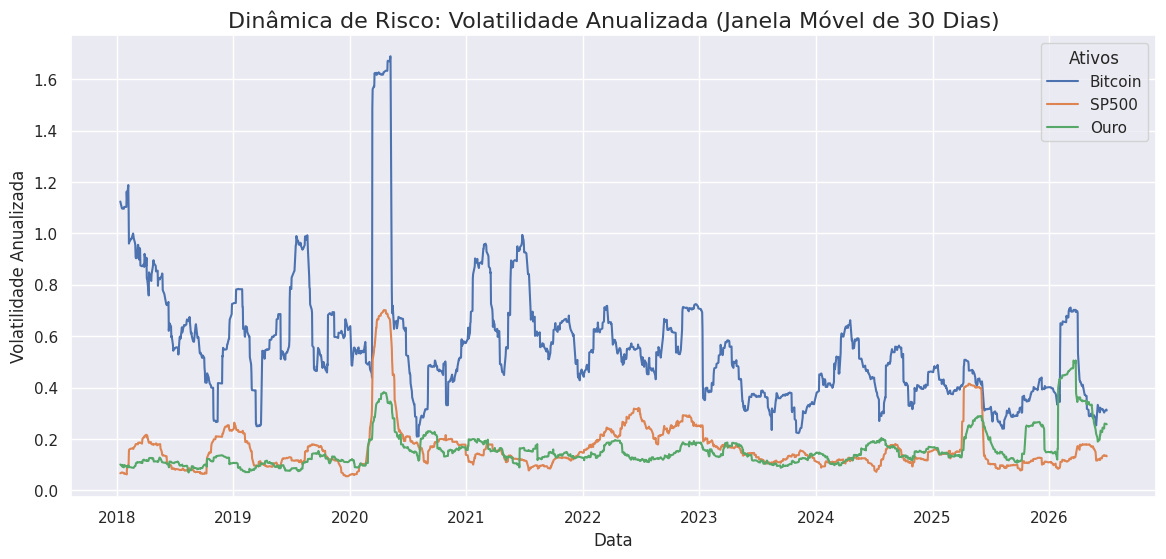

In [87]:
# Definição do tamanho da janela móvel em dias úteis para cálculo de volatilidade
janela = 30

# Cálculo do desvio padrão móvel dos retornos e anualização multiplicando pela raiz de 252
vol_movel = df_retornos_log[['Bitcoin', 'SP500', 'Ouro']].rolling(window=janela).std() * np.sqrt(252)

# Configuração do gráfico de linhas para a volatilidade móvel anualizada
plt.figure(figsize=(14, 6))
sns.lineplot(data=vol_movel, dashes=False, linewidth=1.5)

# Ajustes de legenda, rótulos e título do gráfico
plt.title('Dinâmica de Risco: Volatilidade Anualizada (Janela Móvel de 30 Dias)', fontsize=16)
plt.xlabel('Data', fontsize=12)
plt.ylabel('Volatilidade Anualizada', fontsize=12)
plt.legend(title='Ativos')

# Exibição do gráfico de volatilidade móvel
plt.show()

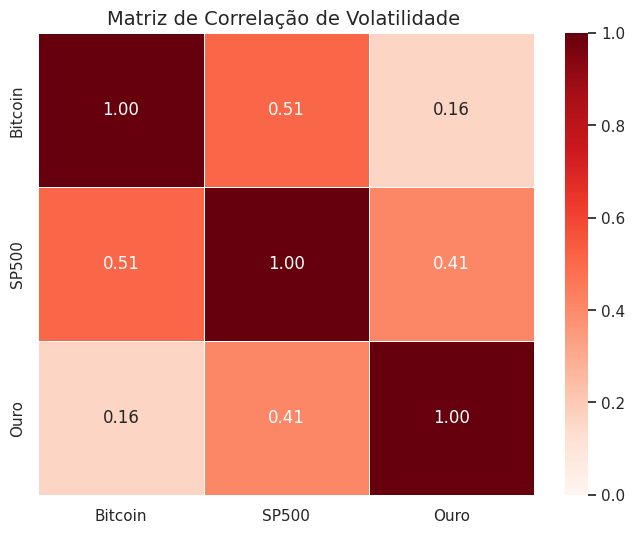

In [88]:
# Definição da janela e cálculo da volatilidade anualizada móvel para Bitcoin, S&P 500 e Ouro
janela = 30
df_volatilidade = df_retornos_log[['Bitcoin', 'SP500', 'Ouro']].rolling(window=janela).std() * np.sqrt(252)

# Remoção de valores nulos iniciais decorrentes da janela móvel
df_volatilidade = df_volatilidade.dropna()

# Cálculo da correlação entre as volatilidades móveis dos ativos para analisar o estresse sistêmico
corr_volatilidade = df_volatilidade.corr()

# Configuração e plotagem do mapa de calor de correlação de volatilidades
plt.figure(figsize=(8, 6))
sns.heatmap(corr_volatilidade, annot=True, cmap='Reds', vmin=0, vmax=1, fmt=".2f", linewidths=0.5)

# Título e exibição do gráfico de correlação de volatilidade
plt.title('Matriz de Correlação de Volatilidade ', fontsize=14)
plt.show()


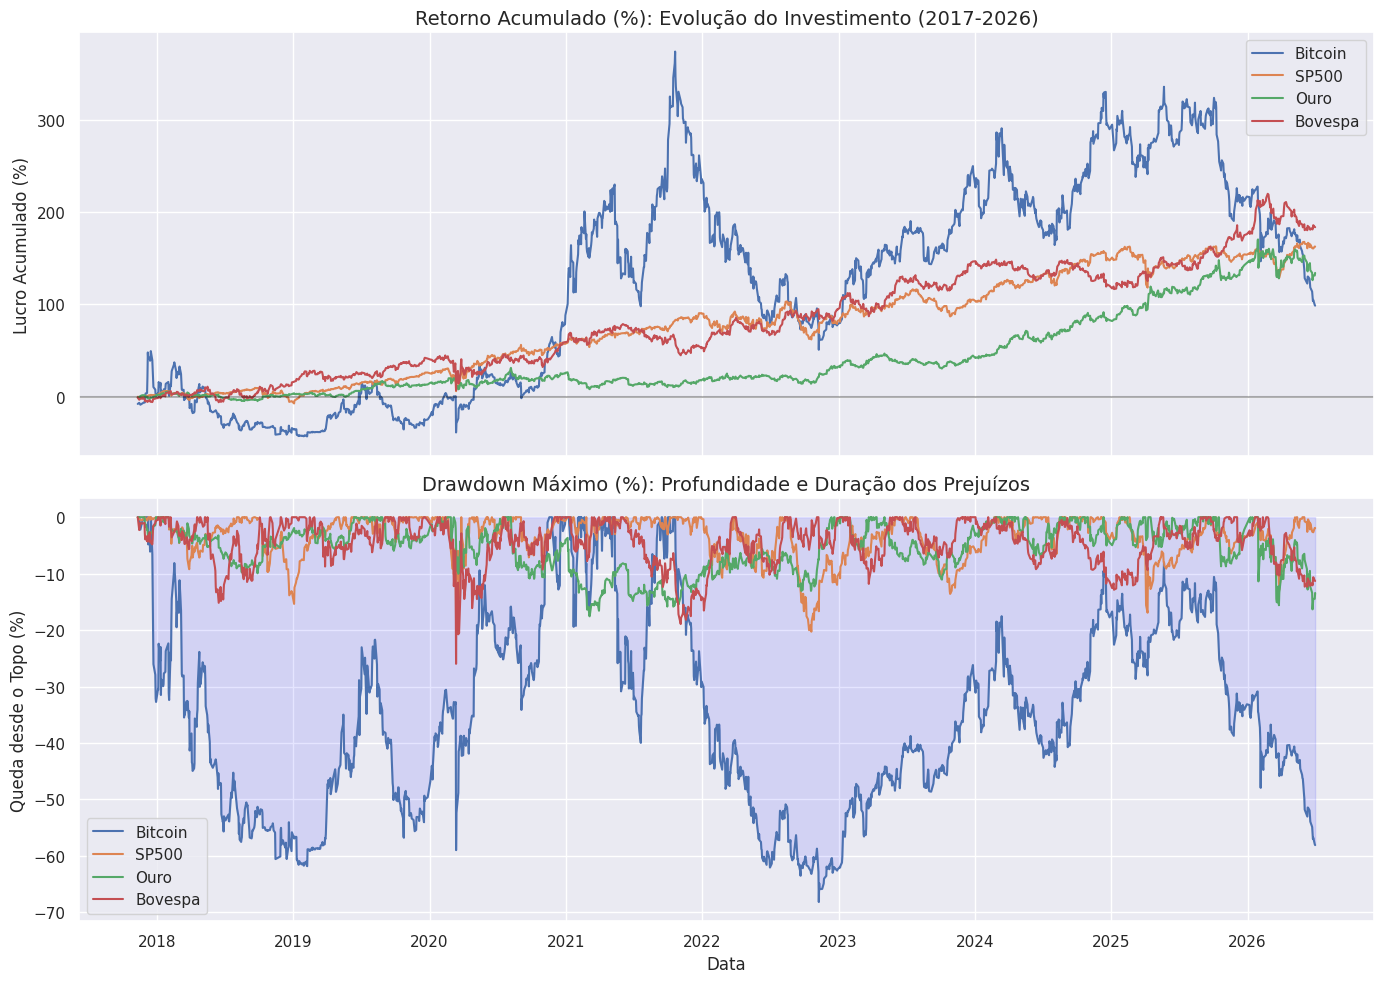

In [89]:
# Cálculo do retorno acumulado de forma exponencial a partir da soma dos retornos logarítmicos
df_acumulado = np.exp(df_retornos_log[['Bitcoin', 'SP500', 'Ouro', 'Bovespa']].cumsum())

# Conversão do retorno acumulado para formato percentual
df_retorno_pct = (df_acumulado - 1) * 100

# Identificação dos picos históricos acumulados (máximo acumulado até cada data)
picos_historicos = df_acumulado.cummax()
# Cálculo do Drawdown diário (queda percentual em relação ao pico histórico atingido anteriormente)
df_drawdown = ((df_acumulado - picos_historicos) / picos_historicos) * 100
# Criação de figura com dois subgráficos compartilhando o mesmo eixo horizontal
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Subgráfico 1: Evolução dos retornos percentuais acumulados
sns.lineplot(data=df_retorno_pct, ax=axes[0], dashes=False, linewidth=1.5)
axes[0].set_title('Retorno Acumulado (%): Evolução do Investimento (2017-2026)', fontsize=14)
axes[0].set_ylabel('Lucro Acumulado (%)', fontsize=12)
axes[0].axhline(0, color='black', linestyle='-', alpha=0.3)

# Subgráfico 2: Evolução do Drawdown dos ativos
sns.lineplot(data=df_drawdown, ax=axes[1], dashes=False, linewidth=1.5)
axes[1].set_title('Drawdown Máximo (%): Profundidade e Duração dos Prejuízos', fontsize=14)
axes[1].set_ylabel('Queda desde o Topo (%)', fontsize=12)
axes[1].set_xlabel('Data', fontsize=12)
axes[1].fill_between(df_drawdown.index, df_drawdown['Bitcoin'], 0, color='blue', alpha=0.1)

# Ajuste de layout e exibição do gráfico duplo
plt.tight_layout()
plt.show()

### 3.3) Bitcoin apresenta Sazonalidade ?

In [79]:
# Seleção do preço de fechamento do Bitcoin com redefinição do índice para análise temporal
df_btc_close = df_btc['Bitcoin'].reset_index(name='Cotação')
# Exibição do DataFrame de cotação do Bitcoin
df_btc_close


,Date,Cotação
0,2012-01-01,5.00
1,2012-01-02,5.00
2,2012-01-03,5.29
3,2012-01-04,5.57
4,2012-01-05,6.65
...,...,...
5291,2026-06-27,59940.07
5292,2026-06-28,59473.29
5293,2026-06-29,60163.86
5294,2026-06-30,58526.17


/tmp/ipykernel_12449/1904313666.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Dia_da_Semana', y='Bitcoin', data=df_btc_sazonalidade, order=ordem_dias, palette='Set2')


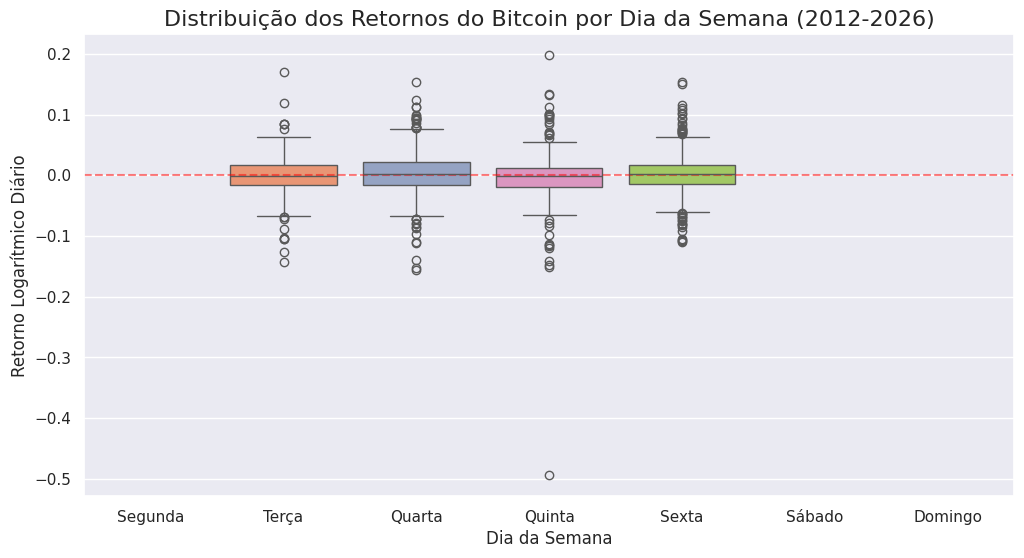

In [94]:
# Criação de uma cópia dos retornos do Bitcoin para análise de sazonalidade semanal
df_btc_sazonalidade = df_retornos_log[['Bitcoin']].copy()

# Extração do dia da semana a partir do índice de data
df_btc_sazonalidade['Dia_da_Semana'] = df_btc_sazonalidade.index.day_name()

# Dicionário de tradução dos dias da semana de inglês para português
dias_pt = {
    'Monday': 'Segunda', 
    'Tuesday': 'Terça', 
    'Wednesday': 'Quarta',
    'Thursday': 'Quinta', 
    'Friday': 'Sexta', 
    'Saturday': 'Sábado', 
    'Sunday': 'Domingo'
}
# Mapeamento e tradução dos dias da semana
df_btc_sazonalidade['Dia_da_Semana'] = df_btc_sazonalidade['Dia_da_Semana'].map(dias_pt)

# Definição da ordem dos dias para exibição no gráfico
ordem_dias = ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo', 'Sábado', 'Domingo']

# Configuração do gráfico boxplot para visualizar a distribuição dos retornos
plt.figure(figsize=(12, 6))
sns.boxplot(x='Dia_da_Semana', y='Bitcoin', data=df_btc_sazonalidade, order=ordem_dias, palette='Set2')

# Linha horizontal tracejada indicando retorno neutro (zero)
plt.axhline(0, color='red', linestyle='--', alpha=0.5)

# Títulos e formatações dos eixos do gráfico de sazonalidade
plt.title('Distribuição dos Retornos do Bitcoin por Dia da Semana (2012-2026)', fontsize=16)
plt.xlabel('Dia da Semana', fontsize=12)
plt.ylabel('Retorno Logarítmico Diário', fontsize=12)

# Exibição do gráfico boxplot
plt.show()


#### Conclusão da Análise de Sazonalidade

### 3.5) O Bticoin possue correlação com outros ativos financeiros ?

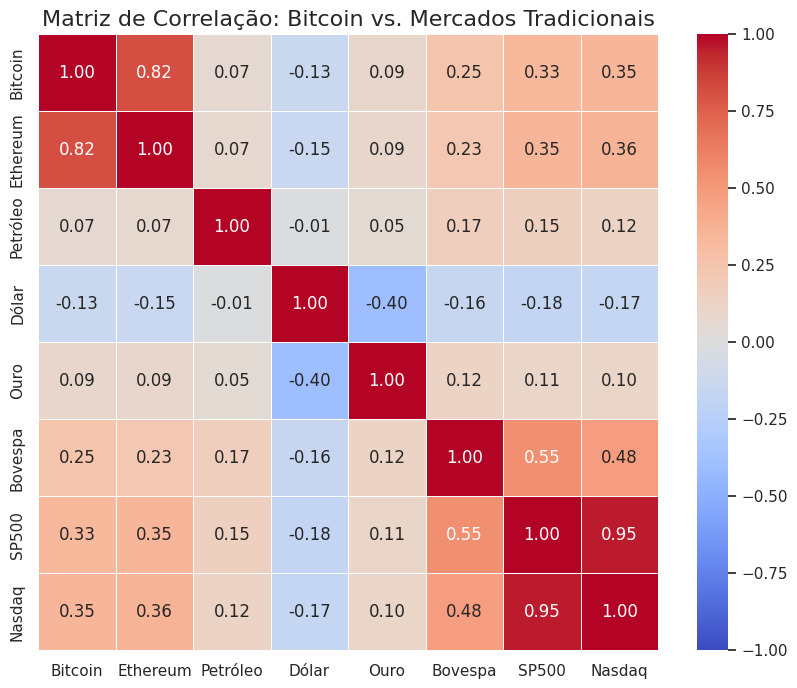

In [81]:
# Garantia de remoção de qualquer valor nulo nos retornos
df_final = df_retornos_log.dropna() 

# Cálculo da matriz de correlação de Pearson entre os retornos dos ativos
matriz_corr = df_final.corr()

# Configuração e plotagem do mapa de calor (heatmap) da matriz de correlação
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_corr, 
            annot=True,
            cmap='coolwarm',
            vmin=-1, vmax=1,
            fmt=".2f",
            linewidths=0.5)

# Configuração de título e exibição do gráfico de correlação
plt.title('Matriz de Correlação: Bitcoin vs. Mercados Tradicionais', fontsize=16)
plt.show()


#### Conclusão sobre a Correlação


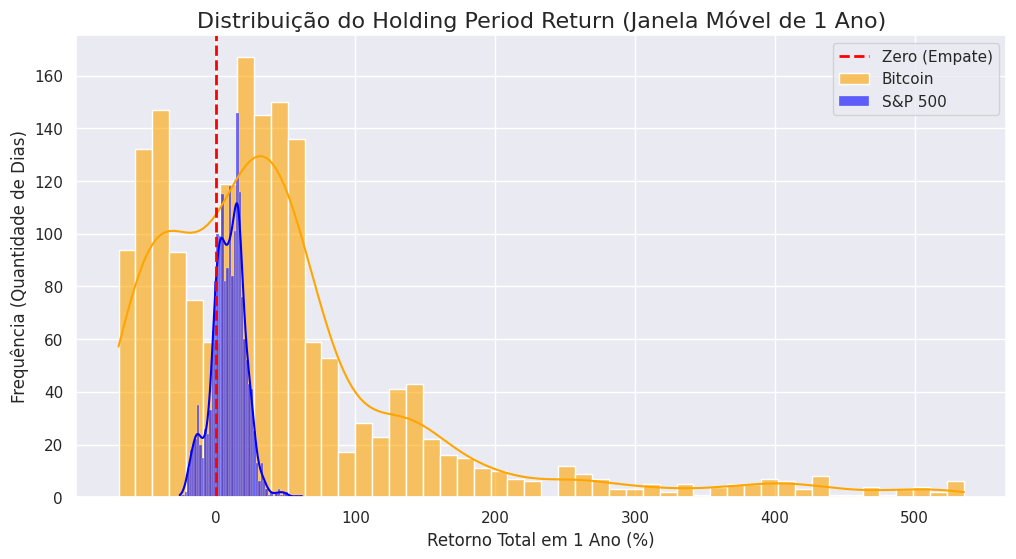

Probabilidade de lucro segurando BTC por 1 ano: 67.2%
Probabilidade de lucro segurando S&P 500 por 1 ano: 80.5%


In [85]:
# Definindo a janela do período de manutenção (ex: 1 ano = 252 dias úteis)
janela_hpr = 252

# Calculando o HPR Móvel (Preço de hoje / Preço de 252 dias atrás - 1)
# Usamos o DataFrame de preços de fechamento originais que foram limpos anteriormente
df_hpr_movel = (df_fechamento / df_fechamento.shift(janela_hpr)) - 1
df_hpr_movel = df_hpr_movel.dropna() * 100 # Em porcentagem

# Plotando a distribuição do HPR de 1 ano (Histograma)
plt.figure(figsize=(12, 6))

sns.histplot(df_hpr_movel['Bitcoin'], bins=50, kde=True, color='orange', alpha=0.6, label='Bitcoin')
sns.histplot(df_hpr_movel['SP500'], bins=50, kde=True, color='blue', alpha=0.6, label='S&P 500')

plt.axvline(0, color='red', linestyle='--', linewidth=2, label='Zero (Empate)')

plt.title('Distribuição do Holding Period Return (Janela Móvel de 1 Ano)', fontsize=16)
plt.xlabel('Retorno Total em 1 Ano (%)', fontsize=12)
plt.ylabel('Frequência (Quantidade de Dias)', fontsize=12)
plt.legend()


plt.show()

# Calculando a probabilidade de lucro (Taxa de Acerto)
prob_lucro_btc = (df_hpr_movel['Bitcoin'] > 0).mean() * 100
prob_lucro_sp = (df_hpr_movel['SP500'] > 0).mean() * 100

print(f"Probabilidade de lucro segurando BTC por 1 ano: {prob_lucro_btc:.1f}%")
print(f"Probabilidade de lucro segurando S&P 500 por 1 ano: {prob_lucro_sp:.1f}%")


#### 4. Disclaimer Final ⚠️
Essa é uma análise exploratória envolvendo dados dos mercados analisados e possui limitações inerentes, pois se baseia exclusivamente na observação de padrões visuais e medidas descritivas. O fato de encontrarmos associações não garante que essas diferenças possuam significância estatística, pois podem ser mero fruto do acaso.
Além disso, o Bitcoin é um ativo recente em comparação com os demais analisados, o que dificulta a análise retrospectiva entre eles.
